# Graphic card thermal analysis

This example shows how to use pyAEDT to create a graphic card setup in
Icepak and postprocess the results.
The example file is an Icepak project with a model that is already created and
has materials assigned.

Keywords: **Icepak**, **boundary conditions**, **postprocessing**, **monitors**.

## Perform imports and define constants

Perform required imports.

In [1]:
import os
import tempfile
import time

import ansys.aedt.core
from ansys.aedt.core.examples.downloads import download_icepak
import pandas as pd
from IPython.display import Image

Define constants.

In [2]:
AEDT_VERSION = "2025.1"
NUM_CORES = 4
NG_MODE = False  # Do not show the graphical user interface.

## Create temporary directory and download project

Create a temporary directory where downloaded data or
dumped data can be stored.
If you'd like to retrieve the project data for subsequent use,
the temporary folder name is given by ``temp_folder.name``.

In [3]:
temp_folder = tempfile.TemporaryDirectory(suffix=".ansys")
project_temp_name = download_icepak(
    local_path=temp_folder.name
)

## Open project

Open the project without the GUI.

In [4]:
ipk = ansys.aedt.core.Icepak(
    project=project_temp_name,
    version=AEDT_VERSION,
    new_desktop=True,
    non_graphical=NG_MODE,
)

PyAEDT INFO: Parsing C:\Users\ansys\AppData\Local\Temp\tmp5fi6idot.ansys\Graphics_card.aedt.


PyAEDT INFO: Python version 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)].


PyAEDT INFO: PyAEDT version 0.18.dev0.


PyAEDT INFO: Initializing new Desktop session.


PyAEDT INFO: Log on console is enabled.


...

PyAEDT INFO: Ansoft.ElectronicsDesktop.2025.1 version started with process ID 2088.


PyAEDT INFO: Project Graphics_card has been opened.


PyAEDT INFO: Active Design set to IcepakDesign1


PyAEDT INFO: Active Design set to IcepakDesign1


PyAEDT INFO: Aedt Objects correctly read


## Plot model and rotate

Plot the model using the pyAEDT-PyVista integration and save the result to a file.
Rotate the model and plot the rotated model again.

PyAEDT INFO: PostProcessor class has been initialized! Elapsed time: 0m 0sec


PyAEDT INFO: Post class has been initialized! Elapsed time: 0m 0sec


PyAEDT INFO: Modeler class has been initialized! Elapsed time: 0m 0sec


C:\actions-runner\_work\pyaedt-examples\pyaedt-examples\.venv\lib\site-packages\pyvista\jupyter\notebook.py:37: UserWarning: Failed to use notebook backend: 

Please install `ipywidgets`.

Falling back to a static output.
  warnings.warn(


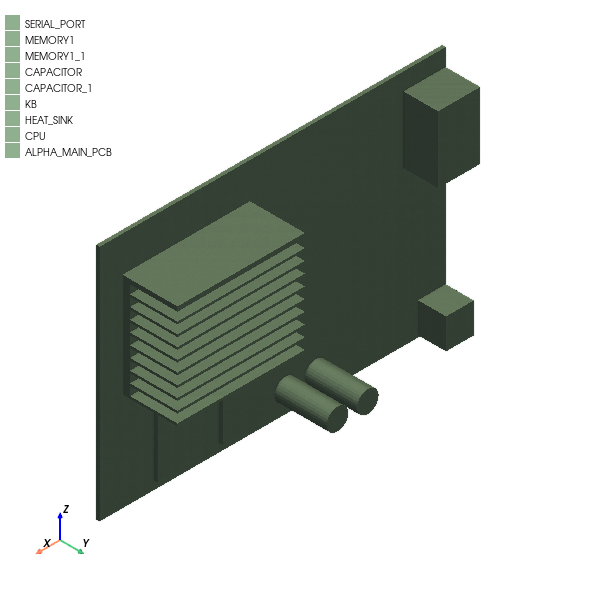

C:\actions-runner\_work\pyaedt-examples\pyaedt-examples\.venv\lib\site-packages\pyvista\jupyter\notebook.py:37: UserWarning: Failed to use notebook backend: 

Please install `ipywidgets`.

Falling back to a static output.
  warnings.warn(


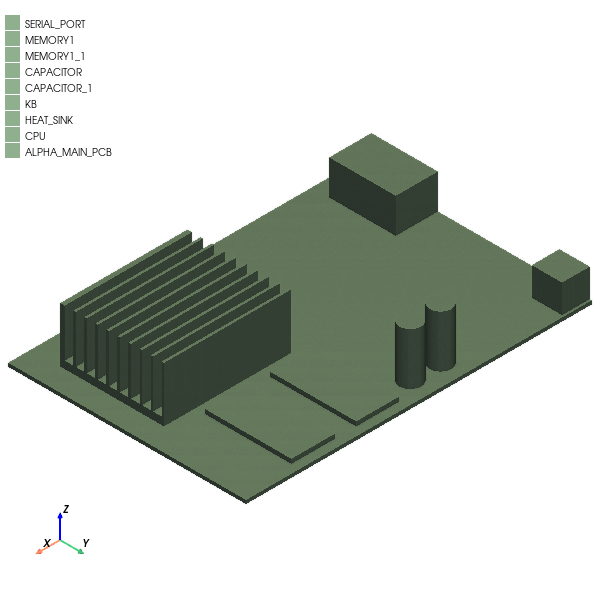

In [5]:
plot1 = ipk.plot(
    show=False,
    output_file=os.path.join(temp_folder.name, "Graphics_card_1.jpg"),
    plot_air_objects=False,
)

ipk.modeler.rotate(ipk.modeler.object_names, "X")

plot2 = ipk.plot(
    show=False,
    output_file=os.path.join(temp_folder.name, "Graphics_card_2.jpg"),
    plot_air_objects=False,
)

## Define boundary conditions

Create source blocks on the CPU and memories.

In [6]:
ipk.create_source_block(object_name="CPU", input_power="25W")
ipk.create_source_block(object_name=["MEMORY1", "MEMORY1_1"], input_power="5W")

PyAEDT INFO: Materials class has been initialized! Elapsed time: 0m 0sec


PyAEDT INFO: Boundary Block CPU has been created.


PyAEDT INFO: Boundary Block MEMORY1 has been created.


The air region object handler is used to specify the inlet (fixed velocity condition) and outlet
(fixed pressure condition) at x_max and x_min.

In [7]:
region = ipk.modeler["Region"]
ipk.assign_pressure_free_opening(
    assignment=region.top_face_x.id, boundary_name="Outlet"
)
ipk.assign_velocity_free_opening(
    assignment=region.bottom_face_x.id,
    boundary_name="Inlet",
    velocity=["1m_per_sec", "0m_per_sec", "0m_per_sec"],
)

PyAEDT INFO: Boundary Opening Outlet has been created.


PyAEDT INFO: Boundary Opening Inlet has been created.


## Assign mesh settings

### Assign mesh region
Assign a mesh region around the heat sink and CPU.

In [8]:
mesh_region = ipk.mesh.assign_mesh_region(assignment=["HEAT_SINK", "CPU"])

PyAEDT WARNING: Property Command is read-only.


PyAEDT INFO: Mesh class has been initialized! Elapsed time: 0m 0sec


PyAEDT WARNING: Property Command is read-only.


PyAEDT WARNING: Property Command is read-only.


Print the available settings for the mesh region

In [9]:
mesh_region.settings

{'EnableTransition': False, 'ProximitySizeFunction': True, 'CurvatureSizeFunction': True, 'OptimizePCBMesh': True, 'EnforceCutCellMeshing': False, 'MeshRegionResolution': 5, 'Enable2DCutCell': False, 'Enforce2dot5DCutCell': False, 'StairStepMeshing': False}

Set the mesh region settings to manual and see newly available settings.

In [10]:
mesh_region.manual_settings = True
mesh_region.settings

{'EnableTransition': False, 'MaxElementSizeZ': '0.03mm', 'CurvatureSizeFunction': True, 'MaxElementSizeY': '0.02mm', 'EnableMLM': True, 'UniformMeshParametersType': 'Average', 'MinGapY': '1mm', '2DMLMType': '2DMLM_None', 'MinGapX': '1mm', 'MaxLevels': '0', 'MaxElementSizeX': '0.02mm', 'OptimizePCBMesh': True, 'EnforeMLMType': '3D', 'MinGapZ': '1mm', 'MaxSizeRatio': '2', 'ProximitySizeFunction': True, 'BufferLayers': '0', 'MinElementsInGap': '3', 'NoOGrids': False, 'EnforceCutCellMeshing': False, 'MinElementsOnEdge': '2', 'Enable2DCutCell': False, 'Enforce2dot5DCutCell': False, 'StairStepMeshing': False}

Modify settings and update.

In [11]:
mesh_region.settings["MaxElementSizeX"] = "2mm"
mesh_region.settings["MaxElementSizeY"] = "2mm"
mesh_region.settings["MaxElementSizeZ"] = "2mm"
mesh_region.settings["EnableMLM"] = True
mesh_region.settings["MaxLevels"] = "2"
mesh_region.settings["MinElementsInGap"] = 4
mesh_region.update()

True

Modify the slack of the subregion around the objects.

In [12]:
subregion = mesh_region.assignment
subregion.positive_x_padding = "20mm"
subregion.positive_y_padding = "5mm"
subregion.positive_z_padding = "5mm"
subregion.negative_x_padding = "5mm"
subregion.negative_y_padding = "5mm"
subregion.negative_z_padding = "10mm"

PyAEDT WARNING: Property Command is read-only.


PyAEDT WARNING: Property Command is read-only.


PyAEDT WARNING: Property Command is read-only.


PyAEDT WARNING: Property Command is read-only.


PyAEDT WARNING: Property Command is read-only.


...

PyAEDT WARNING: Property Command is read-only.


PyAEDT WARNING: Property Command is read-only.


PyAEDT WARNING: Property Command is read-only.


PyAEDT WARNING: Property Command is read-only.


PyAEDT WARNING: Property Command is read-only.


## Assign monitors

Assign a temperature face monitor to the CPU face in contact with the heatsink.

In [13]:
cpu = ipk.modeler["CPU"]
m1 = ipk.monitor.assign_face_monitor(
    face_id=cpu.top_face_z.id,
    monitor_quantity="Temperature",
    monitor_name="TemperatureMonitor1",
)

Assign multiple speed point monitors downstream of the assembly.

In [14]:
speed_monitors = []
for x_pos in range(0, 10, 2):
    m = ipk.monitor.assign_point_monitor(
        point_position=[f"{x_pos}mm", "40mm", "15mm"], monitor_quantity="Speed"
    )
    speed_monitors.append(m)

## Solve project

Create a setup, modify solver settings, and run the simulation.

In [15]:
setup1 = ipk.create_setup()
setup1.props["Flow Regime"] = "Turbulent"
setup1.props["Convergence Criteria - Max Iterations"] = 5
setup1.props["Linear Solver Type - Pressure"] = "flex"
setup1.props["Linear Solver Type - Temperature"] = "flex"
ipk.save_project()
ipk.analyze(setup=setup1.name, cores=NUM_CORES, tasks=NUM_CORES)

PyAEDT INFO: Project Graphics_card Saved correctly


PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/Icepak correctly changed.


PyAEDT INFO: Solving design setup Setup


PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/Icepak correctly changed.


PyAEDT INFO: Design setup Setup solved correctly in 0.0h 3.0m 7.0s


True

## Postprocess

### Perform quantitative postprocessing

Get the point monitor data. A dictionary is returned with ``'Min'``, ``'Max'``, and ``'Mean'`` keys.

In [16]:
temperature_data = ipk.post.evaluate_monitor_quantity(
    monitor=m1, quantity="Temperature"
)
temperature_data

{'Min': '59.8675',
 'Max': '59.8675',
 'Mean': '59.8675',
 'Stdev': '0',
 'Unit': 'C'}

It is also possible to get the data as a Pandas dataframe for advanced postprocessing.

In [17]:
speed_fs = ipk.post.create_field_summary()
for m_name in speed_monitors:
    speed_fs.add_calculation(
        entity="Monitor", geometry="Volume", geometry_name=m_name, quantity="Speed"
    )
speed_data = speed_fs.get_field_summary_data(pandas_output=True)

All the data is now in a dataframe, making it easy to visualize and manipulate.

In [18]:
speed_data.head()

,Entity Type,Geometry Type,Entity,Quantity,Side,Normal,Mesh,Min,Max,Mean,Stdev,Area/Volume,Variation
0,Monitor,Volume,Monitor_BCJU1K,Speed[m/s],Default,,All,0.245263,0.245263,0.245263,0,0 m^3,
1,Monitor,Volume,Monitor_CWIXR7,Speed[m/s],Default,,All,0.260956,0.260956,0.260956,0,0 m^3,
2,Monitor,Volume,Monitor_SX9W47,Speed[m/s],Default,,All,0.329172,0.329172,0.329172,0,0 m^3,
3,Monitor,Volume,Monitor_K5N94V,Speed[m/s],Default,,All,0.336824,0.336824,0.336824,0,0 m^3,
4,Monitor,Volume,Monitor_YWJ2VB,Speed[m/s],Default,,All,0.344669,0.344669,0.344669,0,0 m^3,


The ``speed_data`` dataframe contains data from monitors, so it can be expanded with information
of their position.

In [19]:
for i in range(3):
    direction = ["X", "Y", "Z"][i]
    speed_data["Position" + direction] = [
        ipk.monitor.all_monitors[entity].location[i] for entity in speed_data["Entity"]
    ]

Plot the velocity profile at different X positions

<Axes: xlabel='x [mm]', ylabel='Speed[m/s]'>

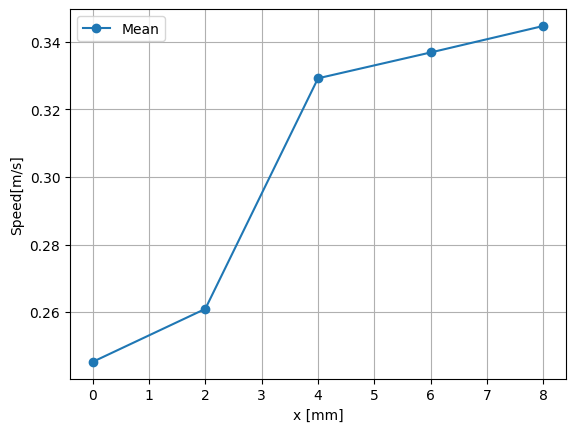

In [20]:
speed_data.plot(
    x="PositionX",
    y="Mean",
    kind="line",
    marker="o",
    ylabel=speed_data.at[0, "Quantity"],
    xlabel=f"x [{ipk.modeler.model_units}]",
    grid=True,
)

Extract temperature data at those same locations (so the ``speed_monitors`` list is used).

In [21]:
temperature_fs = ipk.post.create_field_summary()
for m_name in speed_monitors:
    temperature_fs.add_calculation(
        entity="Monitor",
        geometry="Volume",
        geometry_name=m_name,
        quantity="Temperature",
    )
temperature_fs = temperature_fs.get_field_summary_data(pandas_output=True)
temperature_fs.head()

,Entity Type,Geometry Type,Entity,Quantity,Side,Normal,Mesh,Min,Max,Mean,Stdev,Area/Volume,Variation
0,Monitor,Volume,Monitor_BCJU1K,Temperature[C],Default,,All,56.7363,56.7363,56.7363,0,0 m^3,
1,Monitor,Volume,Monitor_CWIXR7,Temperature[C],Default,,All,52.9035,52.9035,52.9035,0,0 m^3,
2,Monitor,Volume,Monitor_SX9W47,Temperature[C],Default,,All,47.0946,47.0946,47.0946,0,0 m^3,
3,Monitor,Volume,Monitor_K5N94V,Temperature[C],Default,,All,46.3862,46.3862,46.3862,0,0 m^3,
4,Monitor,Volume,Monitor_YWJ2VB,Temperature[C],Default,,All,45.6778,45.6778,45.6778,0,0 m^3,


The two dataframes can be merged using the `pd.merge()` function. With the merge, suffixes are
added to the column names to differentiate between the columns from each original dataframe.

In [22]:
merged_df = pd.merge(
    temperature_fs, speed_data, on="Entity", suffixes=("_temperature", "_speed")
)
merged_df.head()

,Entity Type_temperature,Geometry Type_temperature,Entity,Quantity_temperature,Side_temperature,Normal_temperature,Mesh_temperature,Min_temperature,Max_temperature,Mean_temperature,...,Mesh_speed,Min_speed,Max_speed,Mean_speed,Stdev_speed,Area/Volume_speed,Variation_speed,PositionX,PositionY,PositionZ
0,Monitor,Volume,Monitor_BCJU1K,Temperature[C],Default,,All,56.7363,56.7363,56.7363,...,All,0.245263,0.245263,0.245263,0,0 m^3,,0.0,40.0,15.0
1,Monitor,Volume,Monitor_CWIXR7,Temperature[C],Default,,All,52.9035,52.9035,52.9035,...,All,0.260956,0.260956,0.260956,0,0 m^3,,2.0,40.0,15.0
2,Monitor,Volume,Monitor_SX9W47,Temperature[C],Default,,All,47.0946,47.0946,47.0946,...,All,0.329172,0.329172,0.329172,0,0 m^3,,4.0,40.0,15.0
3,Monitor,Volume,Monitor_K5N94V,Temperature[C],Default,,All,46.3862,46.3862,46.3862,...,All,0.336824,0.336824,0.336824,0,0 m^3,,6.0,40.0,15.0
4,Monitor,Volume,Monitor_YWJ2VB,Temperature[C],Default,,All,45.6778,45.6778,45.6778,...,All,0.344669,0.344669,0.344669,0,0 m^3,,8.0,40.0,15.0


The column names are renamed based on the ``Quantity`` column of the original dataframes.
Finally, only the ``'Entity'``, ``'Mean_temperature'``, and ``'Mean_speed'`` columns are selected and
assigned to the merged dataframe.

In [23]:
temperature_quantity = temperature_fs["Quantity"].iloc[0]
velocity_quantity = speed_data["Quantity"].iloc[0]
merged_df.rename(
    columns={"Mean_temperature": temperature_quantity, "Mean_speed": velocity_quantity},
    inplace=True,
)
merged_df = merged_df[
    [
        "Entity",
        temperature_quantity,
        velocity_quantity,
        "PositionX",
        "PositionY",
        "PositionZ",
    ]
]
merged_df.head()

,Entity,Temperature[C],Speed[m/s],PositionX,PositionY,PositionZ
0,Monitor_BCJU1K,56.7363,0.245263,0.0,40.0,15.0
1,Monitor_CWIXR7,52.9035,0.260956,2.0,40.0,15.0
2,Monitor_SX9W47,47.0946,0.329172,4.0,40.0,15.0
3,Monitor_K5N94V,46.3862,0.336824,6.0,40.0,15.0
4,Monitor_YWJ2VB,45.6778,0.344669,8.0,40.0,15.0


Compute the correlation coefficient between velocity and temperature from the merged dataframe
and plot a scatter plot to visualize their relationship.

Text(0.5, 1.0, 'Correlation between Temperature and Velocity: -0.99')

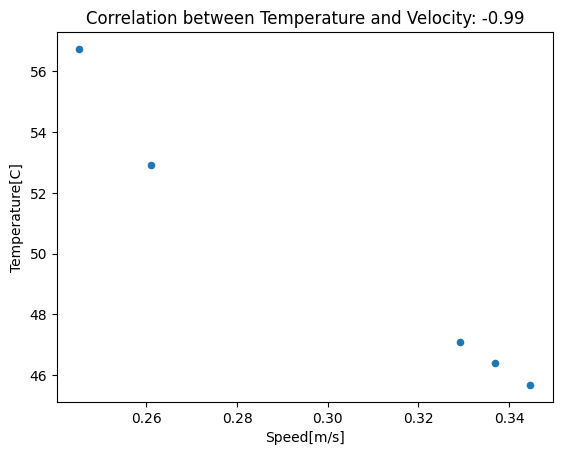

In [24]:
correlation = merged_df[velocity_quantity].corr(merged_df[temperature_quantity])
ax = merged_df.plot.scatter(x=velocity_quantity, y=temperature_quantity)
ax.set_xlabel(velocity_quantity)
ax.set_ylabel(temperature_quantity)
ax.set_title(f"Correlation between Temperature and Velocity: {correlation:.2f}")

The further away from the assembly, the faster and colder the air due to mixing.
Despite being extremely simple, this example demonstrates the potential of importing field
summary data into Pandas.

### Perform qualitative Postprocessing
Create a temperature plot on main components and export it to a PNG file.

PyAEDT INFO: Active Design set to IcepakDesign1


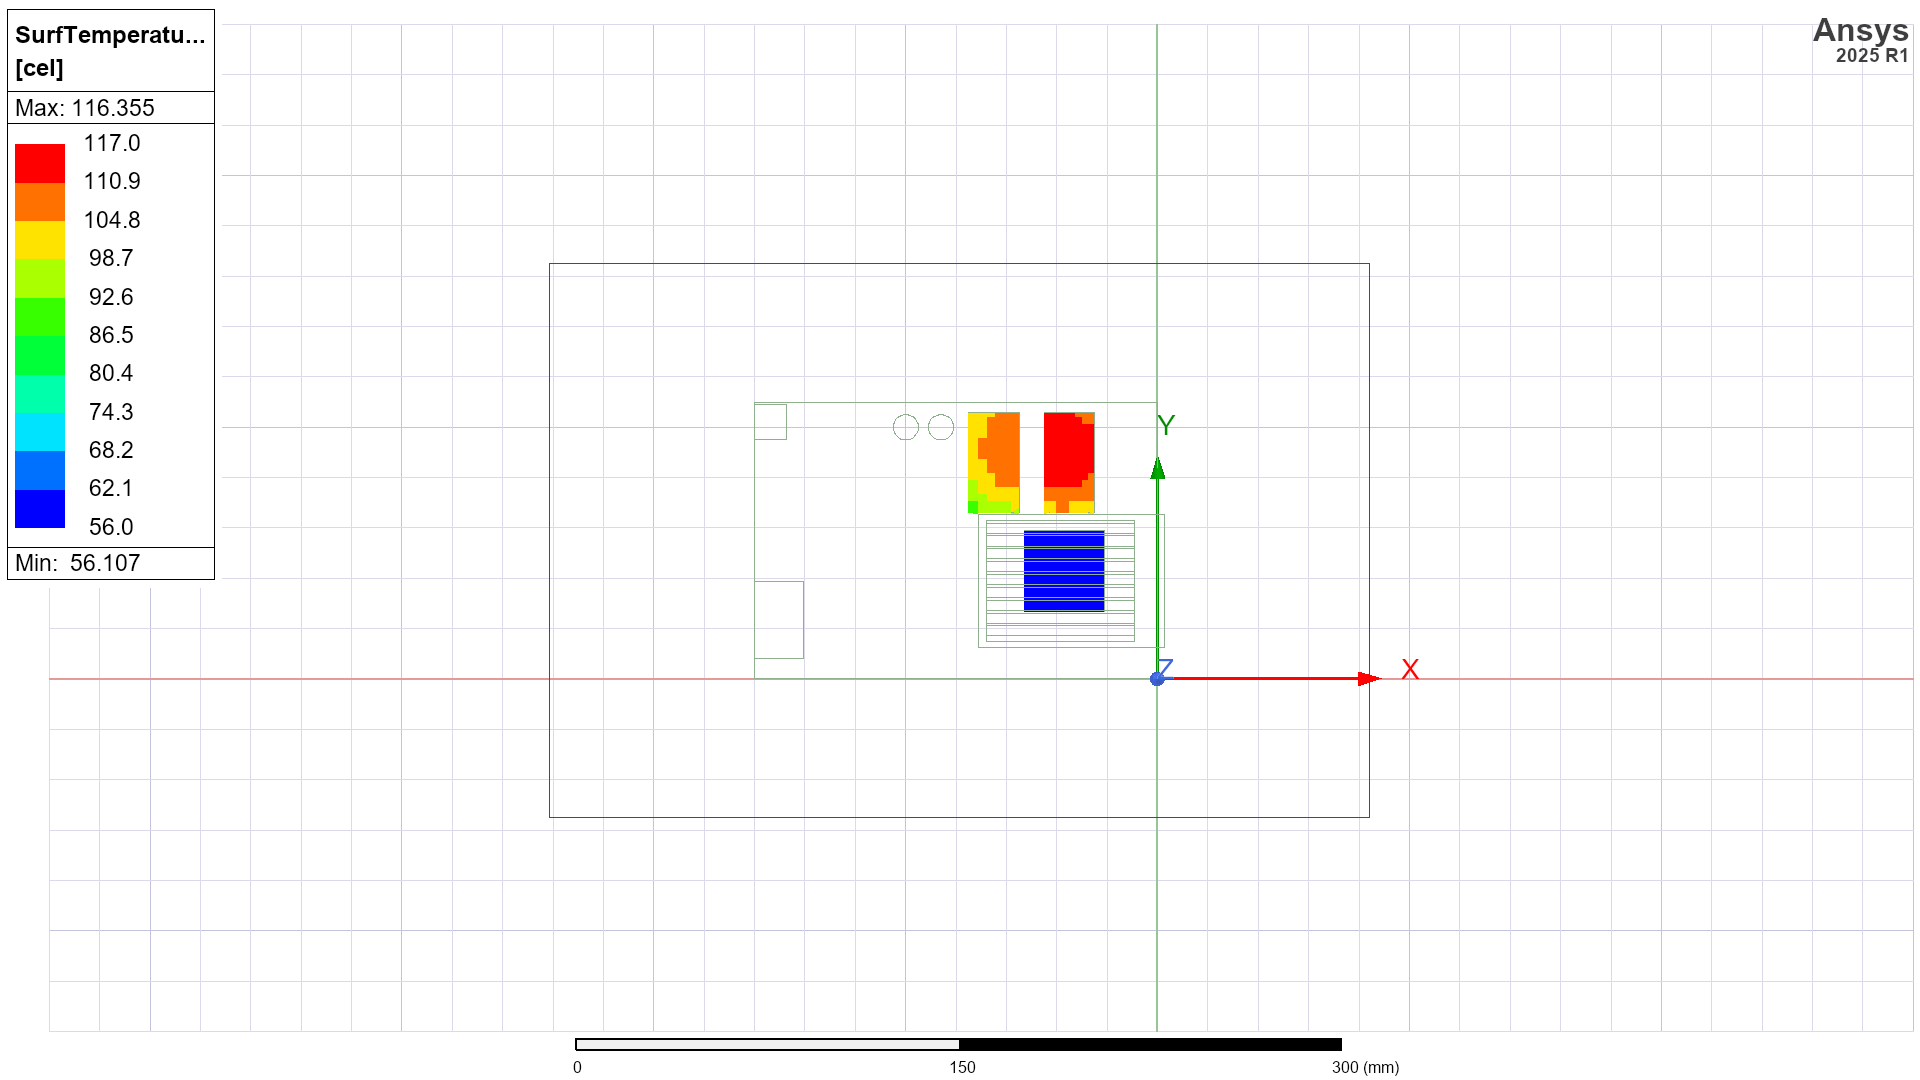

In [25]:
surflist = [i.id for i in ipk.modeler["CPU"].faces]
surflist += [i.id for i in ipk.modeler["MEMORY1"].faces]
surflist += [i.id for i in ipk.modeler["MEMORY1_1"].faces]
plot3 = ipk.post.create_fieldplot_surface(
    assignment=surflist, quantity="SurfTemperature"
)
path = plot3.export_image(
    full_path=os.path.join(temp_folder.name, "temperature.png"),
    orientation="top",
    show_region=False,
)
Image(filename=path)  # Display the image

Use PyVista to display the temperature map.

PyAEDT INFO: Active Design set to IcepakDesign1


C:\actions-runner\_work\pyaedt-examples\pyaedt-examples\.venv\lib\site-packages\pyvista\jupyter\notebook.py:37: UserWarning: Failed to use notebook backend: 

Please install `ipywidgets`.

Falling back to a static output.
  warnings.warn(


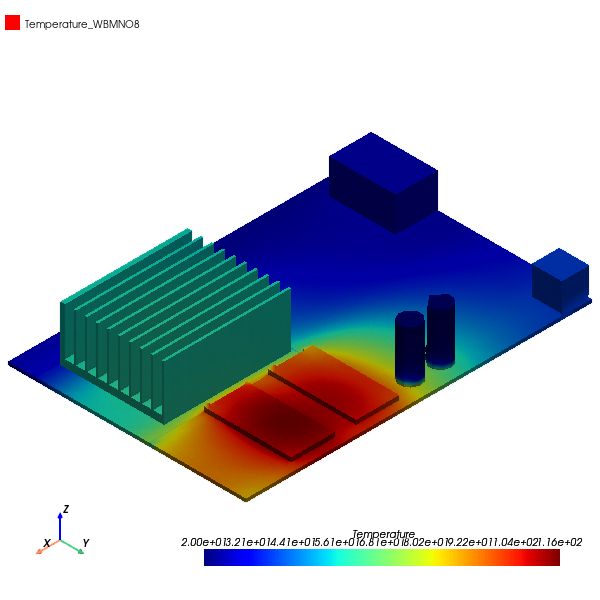

In [26]:
plot4 = ipk.post.plot_field(
    quantity="Temperature",
    assignment=[
        "SERIAL_PORT",
        "MEMORY1",
        "MEMORY1_1",
        "CAPACITOR",
        "CAPACITOR_1",
        "KB",
        "HEAT_SINK",
        "CPU",
        "ALPHA_MAIN_PCB",
    ],
    plot_cad_objs=False,
    show=False,
    export_path=temp_folder.name,
)

## Release AEDT

In [27]:
ipk.save_project()
ipk.release_desktop()
# Wait 3 seconds to allow AEDT to shut down before cleaning the temporary directory.
time.sleep(3)

PyAEDT INFO: Project Graphics_card Saved correctly


PyAEDT INFO: Desktop has been released and closed.


## Clean up

All project files are saved in the folder ``temp_folder.name``.
If you've run this example as a Jupyter notebook, you
can retrieve those project files. The following cell
removes all temporary files, including the project folder.

In [28]:
temp_folder.cleanup()